In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage
from agents.analyst import analyst_node
from agents.extended_analyst import extended_analyst_node
from agents.first_hitl import first_hitl_analyst_node
from graph.agent_state import AgentState
from graph.graph_helpers import run_graph_with_hitl

In [ ]:
from graph.agent_state import AgentState

def correlation_node(state: AgentState) -> dict:
    pass
    return {
        "extended_analysis": result
    }

In [2]:
builder = StateGraph(AgentState)

builder.add_node("analyst_node", analyst_node)
builder.add_node("extended_analyst_node", extended_analyst_node)
builder.add_node("first_hitl_analyst_node", first_hitl_analyst_node)


builder.add_edge(START, "analyst_node")
builder.add_edge("analyst_node", "extended_analyst_node")
builder.add_edge("extended_analyst_node", "first_hitl_analyst_node")
builder.add_edge("first_hitl_analyst_node", END)

graph = builder.compile()

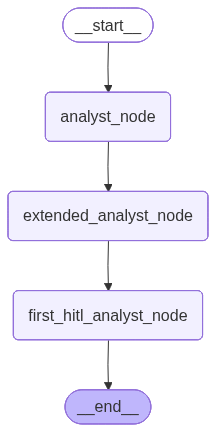

In [3]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_ascii())

In [4]:
from langgraph.checkpoint.memory import MemorySaver

query = """
    Во вложении датасет, который описывает данные банковских клиентов.
    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status
    Уникальный идентификатор клиента - Application ID
"""

initial_state = {"messages": [HumanMessage(content=query)], "file_path": "test_data/Train_Set_90621.parquet"}
config={"configurable": {"thread_id": "test"}}

graph = builder.compile(checkpointer=MemorySaver())

result = run_graph_with_hitl(graph, initial_state, config)


Подтвердите таргет для обучения
current_value: Default_Status
hint: Введите название колонки или 'ok' для подтверждения

Подтвердите колонки-идентификаторы для удаления
current_value: ['Application ID', 'Company Branch Code']
hint: Введите список через запятую или 'ok' для подтверждения


In [5]:
result

{'messages': [HumanMessage(content='\n    Во вложении датасет, который описывает данные банковских клиентов.\n    Необходимо решить задачу бинарной классификации, таргетом выступает столбец Default_Status\n    Уникальный идентификатор клиента - Application ID\n', additional_kwargs={}, response_metadata={}, id='5220e97a-6cfc-4c28-bef0-7591619052e4'),
  AIMessage(content='По данным заявок на бизнес-кредит требуется предсказать целевую переменную Default_Status (вероятность/факт дефолта по заявке). В датасете представлены сведения о банке, заявителе и параметрах кредита (суммы, срок, ставка, занятость, документы и т.п.), а также временные признаки одобрения (Approved_Timestamp/Approved_Year).', additional_kwargs={}, response_metadata={}, id='d7530461-d540-4bde-b8b3-f605fabc9432', tool_calls=[], invalid_tool_calls=[])],
 'file_path': 'test_data/Train_Set_90621.parquet',
 'df_columns': ['Application ID',
  'Bank Masked',
  'Bank Type',
  'Approved_Timestamp',
  'Name Masked',
  'Business Ow